# Model Evaluation

## Objective

This notebook evaluates the performance of the final selected machine learning model.

Evaluation includes:

- Classification Report
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Error Analysis

The objective is to assess both predictive performance and model reliability before deployment.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
import joblib

from src.data.dataset_manager import DatasetManager

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

In [3]:
dataset_manager = DatasetManager()

X_train_processed, X_test_processed, y_train, y_test = (
    dataset_manager.load_processed_data()
)

✅ Processed datasets loaded successfully.


In [4]:
best_model = joblib.load(
    "../artifacts/best_model.pkl"
)

label_encoder = joblib.load(
    "../artifacts/label_encoder.pkl"
)

In [5]:
y_test_encoded = label_encoder.transform(y_test)

In [6]:
y_pred = best_model.predict(
    X_test_processed
)

In [7]:
accuracy = accuracy_score(
    y_test_encoded,
    y_pred
)

precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

In [8]:
evaluation = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Score":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

evaluation

,Metric,Score
0,Accuracy,0.965678
1,Precision,0.965667
2,Recall,0.965678
3,F1 Score,0.964160


In [9]:
print(

    classification_report(

        y_test_encoded,

        y_pred,

        target_names=label_encoder.classes_

    )

)

              precision    recall  f1-score   support

     at-risk       0.97      1.00      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.97      0.77      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.90    138018
weighted avg       0.97      0.97      0.96    138018



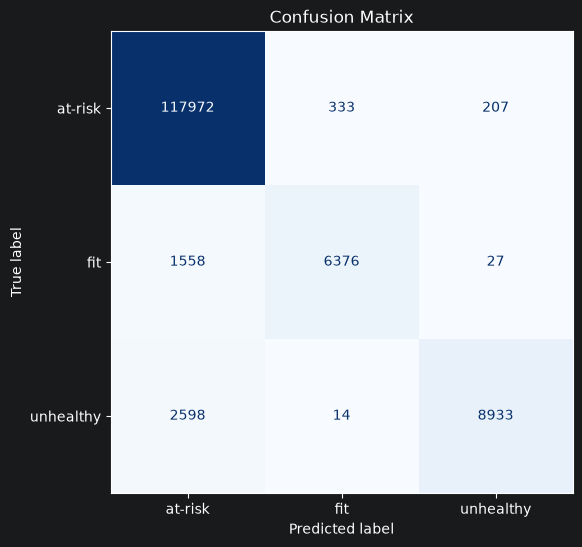

In [10]:
cm = confusion_matrix(

    y_test_encoded,

    y_pred

)

display = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=label_encoder.classes_

)

fig, ax = plt.subplots(figsize=(8, 6))

display.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")

plt.show()

In [11]:
pd.Series(
    label_encoder.inverse_transform(y_pred)
).value_counts()

at-risk      122128
unhealthy      9167
fit            6723
Name: count, dtype: int64

In [12]:
errors = X_test_processed.copy()

errors["Actual"] = label_encoder.inverse_transform(
    y_test_encoded
)

errors["Predicted"] = label_encoder.inverse_transform(
    y_pred
)

misclassified = errors[
    errors["Actual"] != errors["Predicted"]
]

misclassified.head(10)

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_non-veg,diet_type_veg,...,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_other,Actual,Predicted
70,-0.002430,-1.291329,-0.889009,0.214930,-0.288088,0.295526,-0.771495,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,at-risk,fit
142,-1.066575,0.184044,-0.628457,0.777599,0.176323,-1.688474,-1.667654,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,unhealthy,at-risk
150,-0.944460,-1.291329,0.360828,-1.485049,-0.877918,-0.502165,1.100482,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,unhealthy,at-risk
176,-0.002430,0.331581,-1.003000,0.149085,0.996431,0.793230,0.383555,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,unhealthy,at-risk
179,-0.892125,-0.861012,-0.762804,-0.156193,-0.475189,0.213711,-0.711751,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,at-risk,unhealthy
207,-0.002430,-1.893773,-0.416758,0.942209,1.331568,1.454563,-0.034653,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,at-risk,fit
211,0.738983,-1.291329,-0.534821,1.394140,0.664121,0.411429,-1.070214,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,fit,at-risk
292,-1.118910,-0.738064,0.548100,0.475314,1.139841,-0.536254,0.343725,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,unhealthy,at-risk
347,0.180743,-0.455285,-2.541887,0.107184,1.168625,-0.004460,-0.213885,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,at-risk,fit
361,-2.305170,-0.774949,1.293116,-1.395261,-0.991772,0.043265,-0.014738,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,unhealthy,at-risk


# Model Evaluation Summary

## Key Findings

- The LightGBM model achieved the highest overall predictive performance.
- Classification metrics indicate strong and balanced performance across all target classes.
- The confusion matrix shows that most observations were classified correctly.
- Misclassification cases were limited and can be further analysed to improve future model versions.

The model demonstrates sufficient predictive capability to proceed to the explainability stage before deployment.